# P6: Reconocedor de dígitos con GMM-HMM

**Contenido del notebook.**

En esta práctica usamos audios reales del **Free Spoken Digit Dataset**. La idea es entrenar un HMM left-to-right por dígito, extraer MFCC y clasificar una nueva grabación por máxima verosimilitud.

Para que el notebook sea liviano, usamos una gaussiana diagonal por estado. Sin embargo, el ejercicio 1 cuenta parámetros para el caso general $M=4$.

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

from collections import defaultdict
from IPython.display import Audio, display
from pathlib import Path
from scipy.special import logsumexp
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

np.random.seed(7) # hacemos que el notebook sea reproducible
np.set_printoptions(precision=3, suppress=True)

## 1. Conteo de parámetros

In [2]:
W = 10 # dígitos
N = 5 # estados por palabra
M = 4 # componentes gaussianas por estado 
D = 13 # MFCC

### COMPLETAR
pesos_por_estado = M-1
medias_por_estado = M * D
varianzas_por_estado = M * D
emision_por_estado = pesos_por_estado + medias_por_estado + varianzas_por_estado
emision_por_palabra = N * emision_por_estado
transiciones_por_palabra = N-1
total_por_palabra = emision_por_palabra + transiciones_por_palabra
total = total_por_palabra * W

print(f'Emisión por estado:   {emision_por_estado}')
print(f'Emisión por palabra:  {emision_por_palabra}')
print(f'Transiciones/palabra: {transiciones_por_palabra}')
print(f'Total por palabra:    {total_por_palabra}')
print(f'Total sistema:        {total}')

Emisión por estado:   107
Emisión por palabra:  535
Transiciones/palabra: 4
Total por palabra:    539
Total sistema:        5390


## 2. Carga de datos reales: Free Spoken Digit Dataset

El dataset contiene archivos `.wav` de dígitos aislados en inglés. Cada nombre de archivo empieza con el dígito correspondiente.

In [3]:
# Ejecutar una sola vez. Si ya existe la carpeta, no vuelve a descargar
data_dir = Path('free-spoken-digit-dataset/recordings')
if not data_dir.exists():
    print('No se encontró FSDD. Intentando clonar el repositorio...')
    import subprocess, sys
    subprocess.run([
        'git', 'clone', '--depth', '1',
        'https://github.com/Jakobovski/free-spoken-digit-dataset.git'
    ], check=True)
else:
    print('FSDD encontrado.')

wav_paths = sorted(data_dir.glob('*.wav'))
print(f'Cantidad de audios encontrados: {len(wav_paths)}')
print('Ejemplo:', wav_paths[0].name if wav_paths else 'sin archivos')

def etiqueta_digito(path):
    # Formato FSDD: digito_nombre_indice.wav, por ejemplo 3_jackson_12.wav
    return int(path.stem.split('_')[0])

etiquetas_posibles = np.array([etiqueta_digito(p) for p in wav_paths])
print('Dígitos presentes:', sorted(set(etiquetas_posibles.tolist())))

FSDD encontrado.
Cantidad de audios encontrados: 3000
Ejemplo: 0_george_0.wav
Dígitos presentes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [4]:
# Para que corra rápido en clase, tomamos a lo sumo algunos audios por dígito
max_por_digito = 40
rng = np.random.default_rng(0)
seleccion = []
for d in range(10):
    paths_d = [p for p in wav_paths if etiqueta_digito(p) == d]
    paths_d = rng.choice(paths_d, size=min(max_por_digito, len(paths_d)), replace=False)
    seleccion.extend(paths_d.tolist())

seleccion = np.array(seleccion)
todas_etiquetas = np.array([etiqueta_digito(p) for p in seleccion])

paths_train, paths_test, etiquetas_train, etiquetas_test = train_test_split(seleccion, todas_etiquetas, test_size=0.25, stratify=todas_etiquetas, random_state=1)

print(f'Train: {len(paths_train)} audios')
print(f'Test:  {len(paths_test)} audios')
print('Train por dígito:', np.bincount(etiquetas_train, minlength=10))
print('Test por dígito: ', np.bincount(etiquetas_test, minlength=10))

Train: 300 audios
Test:  100 audios
Train por dígito: [30 30 30 30 30 30 30 30 30 30]
Test por dígito:  [10 10 10 10 10 10 10 10 10 10]


## 3. Extracción de MFCC

In [5]:
sr = 8000 #sampling rate
n_mfcc = 13
hop = int(0.010 * sr) # 10 ms
win = int(0.025 * sr) # 25 ms
n_fft = 256

def extraer_mfcc(path):
    audio, sr_audio = librosa.load(path, sr=sr)
    audio, _ = librosa.effects.trim(audio, top_db=25) #recorta silencios marcados al final y al principio
    #El beneficio de usar esto es que le podemos pasar un path directo
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr_audio,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        hop_length=hop,
        win_length=win,
        n_mels=26,
    ).T
    return mfcc.astype(float)

Y_train = [extraer_mfcc(p) for p in paths_train]
Y_test = [extraer_mfcc(p) for p in paths_test]

# Normalización global: se ajusta en train y se aplica a train/test
scaler = StandardScaler()
scaler.fit(np.vstack(Y_train))
Y_train = [scaler.transform(y) for y in Y_train]
Y_test = [scaler.transform(y) for y in Y_test]


print('Ejemplo de secuencia MFCC:', Y_train[0].shape)

C:\Users\Dante P\miniconda3\envs\habla\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ejemplo de secuencia MFCC: (52, 13)


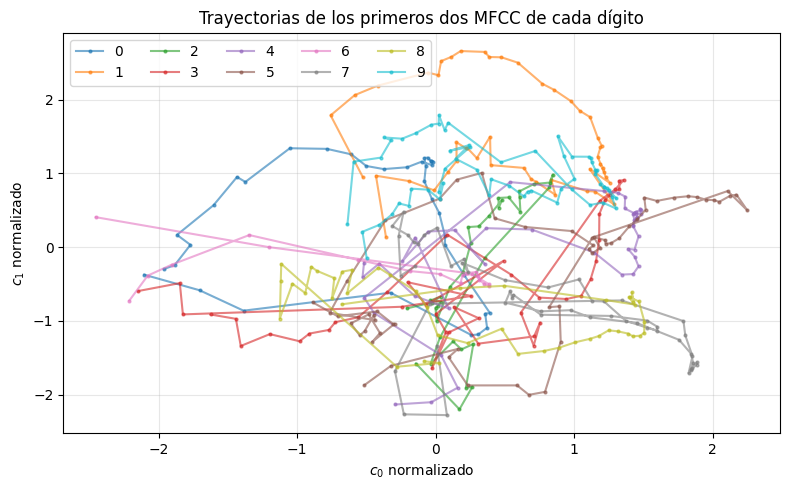

In [6]:
# Visualizamos dos coeficientes MFCC de algunos audios reales
plt.figure(figsize=(8, 5))
for dig in range(10):
    idx = np.where(etiquetas_train == dig)[0][0]
    y = Y_train[idx]
    plt.plot(y[:, 0], y[:, 1], 'o-', markersize=2, alpha=0.6, label=str(dig))
plt.xlabel(r'$c_0$ normalizado')
plt.ylabel(r'$c_1$ normalizado')
plt.title('Trayectorias de los primeros dos MFCC de cada dígito')
plt.legend(ncol=5)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. GMM-HMM left-to-right

En este notebook no vamos a aplicar Baum-Welch. Para cada grabación asignamos los frames a los estados mediante  segmentación uniforme y estimamos los parámetros una sola vez usando asignaciones duras.

In [15]:
def segmentar_uniforme(T, n_estados):
    """Asigna cada frame a un estado mediante una segmentación uniforme fija."""
    if T < n_estados:
        raise ValueError('La secuencia tiene menos frames que estados.')

    cortes = np.linspace(0, T, n_estados + 1).astype(int)
    estados = np.zeros(T, dtype=int)

    for s in range(n_estados):
        ### COMPLETAR 
        estados[cortes[s] : cortes[s+1]] = s

    return estados


def log_gauss_diag(y, mu, var):
    """Log densidad de una gaussiana diagonal para cada fila de y."""
    D = y.shape[1]
    
    return -0.5 * (D * np.log(2 * np.pi) + np.sum(np.log(var)) + np.sum(((y - mu) ** 2) / var, axis=1)) ### <-- COMPLETAR


def estimar_hmm_uniforme(secuencia, n_estados=5, var_floor=1e-2):
    """Entrena un HMM left-to-right con una gaussiana diagonal por estado."""
    D = secuencia[0].shape[1]
    frames_por_estado = [[] for _ in range(n_estados)]
    transiciones = np.ones((n_estados, n_estados)) * 1e-3  # suavizado mínimo

    for y in secuencia:
        estados = segmentar_uniforme(len(y), n_estados)
        for s in range(n_estados):
            frames_por_estado[s].append(y[estados == s])
        for t in range(len(estados) - 1):
            i, j = estados[t], estados[t+1]  ### <-- COMPLETAR 
            if j == i or j == i + 1:
                transiciones[i, j] += 1

    # Forzamos topología left-to-right: self-loop y avance
    A = np.zeros((n_estados, n_estados))
    for i in range(n_estados - 1):
        A[i, i] = transiciones[i, i] ### <-- COMPLETAR 
        A[i, i+1] = transiciones[i, i+1] ### <-- COMPLETAR 
        A[i] /= A[i].sum() ### <-- COMPLETAR 
    A[-1, -1] = 1.0

    mus = np.zeros((n_estados, D))
    vars_ = np.zeros((n_estados, D))
    for s in range(n_estados):
        ys = np.vstack(frames_por_estado[s])
        mus[s] = ys.mean(axis=0) ### <-- COMPLETAR 
        vars_[s] = np.maximum(ys.var(axis=0), var_floor) ### <-- COMPLETAR 

    pi = np.zeros(n_estados)
    pi[0] = 1.0
    return {'pi': pi, 'A': A, 'mu': mus, 'var': vars_}


def log_emisiones(y, modelo):
    return np.column_stack([log_gauss_diag(y, modelo['mu'][s], modelo['var'][s]) for s in range(modelo['mu'].shape[0])])


def log_probabilidades(P):
    """Convierte probabilidades a log, manteniendo los ceros como -inf."""
    P = np.asarray(P, dtype=float)
    logP = np.full(P.shape, -np.inf, dtype=float)

    mask = P > 0
    logP[mask] = np.log(P[mask])

    return logP


def log_forward(logB, pi, A):
    T, N = logB.shape
    log_alpha = np.full((T, N), -np.inf)
    log_pi = log_probabilidades(pi)
    log_A = log_probabilidades(A)

    ### COMPLETAR inicialización
    log_alpha[0] = log_pi + logB[0]

    for t in range(1, T):
        for j in range(N):
            #log_alpha[t, j] = ### <-- COMPLETAR recursión usando logsumexp
            #DE LA ANTERIOR: alpha[t, j] = (alpha[t-1, :] @ A[:, j]) * B[j, y[t]] 
            log_alpha[t, j] = logsumexp( log_alpha[t-1] + log_A[:, j] ) + logB[t, j]

    # Sumamos todos los caminos legales que terminan en el último estado
    #UNA FORMA: score = logsumexp(log_alpha[-1], axis=0) ### <-- COMPLETAR
    score = log_alpha[-1, -1] ### <-- COMPLETAR
    
    
    return score, log_alpha


def log_viterbi(logB, pi, A):
    T, N = logB.shape
    log_delta = np.full((T, N), -np.inf)
    psi = np.zeros((T, N), dtype=int)
    log_pi = log_probabilidades(pi)
    log_A = log_probabilidades(A)

    ### COMPLETAR reutilizando la lógica de P5
    log_delta[0] = log_pi + logB[0]


    for t in range (1, T):
        for j in range(N):
            temp = log_delta[t-1] + log_A[:, j]
            psi[t, j] = np.argmax(temp)
            log_delta[t, j] = temp[psi[t, j]] + logB[t, j]

    path = np.zeros(T, dtype=int)
    path[-1] = N-1
    for t in range (T-2, -1, -1):
        path[t] = psi[t+1, path[t+1]]

    score = log_delta[-1, -1]
    return score, path, log_delta, psi

In [16]:
N = 5
modelos = {}
for dig in range(10):
    secuencia_dig = [Y_train[i] for i in np.where(etiquetas_train == dig)[0]]
    modelos[dig] = estimar_hmm_uniforme(secuencia_dig, n_estados=N) ###<-- COMPLETAR 

print('Modelos entrenados:', list(modelos.keys()))
print('Matriz de transición del dígito 0:')
print(modelos[0]['A'])

Modelos entrenados: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Matriz de transición del dígito 0:
[[0.898 0.102 0.    0.    0.   ]
 [0.    0.901 0.099 0.    0.   ]
 [0.    0.    0.901 0.099 0.   ]
 [0.    0.    0.    0.901 0.099]
 [0.    0.    0.    0.    1.   ]]


## 5. Reconocimiento por máxima verosimilitud

Accuracy: 0.920


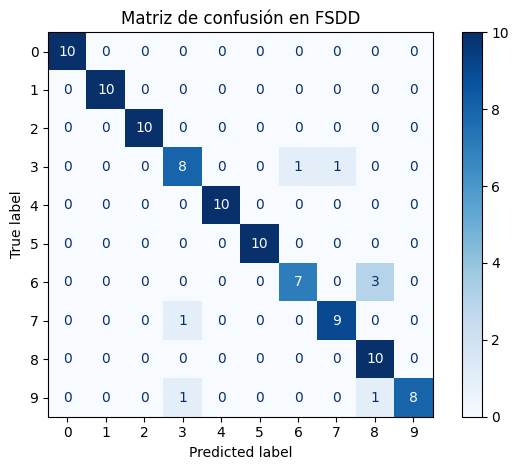

In [17]:
def score_digito(Y, modelo):
    logB = log_emisiones(Y, modelo)
    score, _ = log_forward(logB, modelo['pi'], modelo['A'])
    return score


def predecir(Y):
    scores = {dig: score_digito(Y, modelos[dig]) for dig in range(10)} ### <-- COMPLETAR: calcular un score por dígito
    pred = max(scores, key=scores.get) ### <-- COMPLETAR: quedarse con el mayor 
    return pred, scores
   

y_pred = []
for Y in Y_test:
    pred, _ = predecir(Y)
    y_pred.append(pred)
y_pred = np.array(y_pred)

acc = accuracy_score(etiquetas_test, y_pred)
print(f'Accuracy: {acc:.3f}')

cm = confusion_matrix(etiquetas_test, y_pred, labels=list(range(10))) ### <-- COMPLETAR 
disp = ConfusionMatrixDisplay(cm, display_labels=list(range(10)))
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusión en FSDD')
plt.tight_layout()
plt.show()

## 6. Alineamiento Viterbi

Usamos Viterbi al final únicamente para visualizar un alineamiento.

Dígito verdadero: 4
Dígito predicho:  4


Score forward:  -792.8375198687688
Score Viterbi:  -795.2338248897014


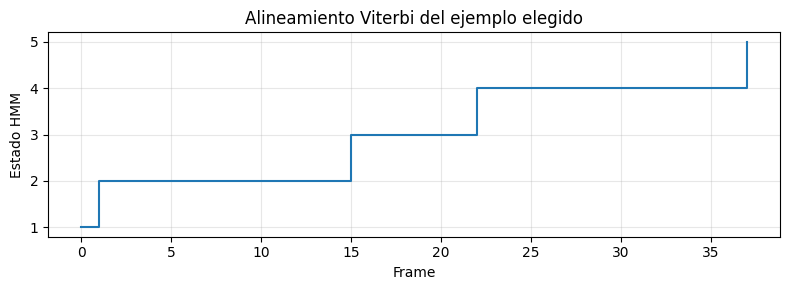

In [18]:
# Elegimos un ejemplo de test y vemos qué estados recorrió el modelo 'ganador'
idx = 0
Y = Y_test[idx]
verdadero = etiquetas_test[idx]
pred, scores = predecir(Y)
modelo = modelos[pred]
logB = log_emisiones(Y, modelo) ### <-- COMPLETAR 
logp_vit, path, log_delta, psi = log_viterbi(logB, modelo['pi'], modelo['A']) ### <-- COMPLETAR 

print('Dígito verdadero:', etiquetas_test[idx])
print('Dígito predicho: ', pred)
display(Audio(filename=str(paths_test[idx])))
print('Score forward: ', scores[pred])
print('Score Viterbi: ', logp_vit)

plt.figure(figsize=(8, 3))
plt.plot(path + 1, drawstyle='steps-post')
plt.xlabel('Frame')
plt.ylabel('Estado HMM')
plt.title('Alineamiento Viterbi del ejemplo elegido')
plt.yticks(range(1, N + 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()